In [102]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

In [103]:
# 복잡한 데이터(차수가 많은), 복잡한 모델(고차원 모델), 적은 데이터
# 과적합 방지 
# 데이터 수 늘리기(현실적으로는 불가능), 복잡한 모델을 단순화(히든 레이터, 뉴런 줄이기)
# 드랍아웃과 같은 별도의 규제 레이어를 추가
# 학습이 잘 되도록 하는 정규화 레이어를 추가

In [104]:
def create_complex_dataset(n_samples = 1200):
    X = torch.randn(n_samples, 20) # (1200, 20)
    # 비선형 및 노이즈 추가
    y = (torch.sin(X[:, 0] * 2) + X[:, 1]**2 - torch.abs(X[:,2]) + torch.randn(n_samples) * 0.1).reshape(-1, 1)   # 이해 잘 안됨
    # 정규화
    y = (y - y.mean()) / y.std()
    return TensorDataset(X, y)

dataset = create_complex_dataset()
train_size = int( 0.8 * len(dataset) )
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)     # 이부분 잘 모르겠음 DataLoader가 뭐하는 거였지??
val_loader = DataLoader(val_dataset, batch_size = 32)


In [105]:
x_batch, y_batch = next( iter(train_loader) )
x_batch.shape, y_batch.shape

(torch.Size([32, 20]), torch.Size([32, 1]))

### Early Stopping Class
- 검증 손실이 개선되지 않을 때 학습을 멈춤

In [106]:
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0, path = 'beest_model.pt'):
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.best_loss = float('inf')           # 왜 inf 인지?
        self.eary_stop = False
        self.counter = 0
    def __call__(self, val_loss, model): # call 이거 뭐하는 건지 이해 안됨
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model.state_dict(), self.path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.eary_stop = True

### 모델 정의(Dropout & Batch Normalization 적용)


In [107]:
class AdvancedModel(nn.Module):
    def __init__(self, input_dim, dropout_p=0.3):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            
            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)
    
model = AdvancedModel(input_dim=20)
print(model)

AdvancedModel(
  (network): Sequential(
    (0): Linear(in_features=20, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


### 학습 루프(시각화)
- 옵티마이저, 손실함수 -> 필수
- early stopping -> 옵션

In [108]:
from tqdm import tqdm
optimizer  = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()
early_stopping = EarlyStopping(patience=5)

epochs = 200
train_loss = []; val_loss = []
pbar = tqdm(range(epochs))
for epoch in pbar:
    batch_train_losses = 0.0; batch_val_losses=0.0

    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        ouput = model(batch_x)
        loss = criterion(ouput, batch_y)
        loss.backward()
        optimizer.step()
        batch_train_losses += loss.item()
    train_loss.append( batch_train_losses / len(train_loader) )

    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            output = model(batch_x)
            loss = criterion(output, batch_y)
            batch_val_losses += loss.item()
        val_loss.append( batch_val_losses / len(val_loader) )

    pbar.set_postfix( {'Train' : f'{train_loss[-1]:.4f}', 'val' : f'{val_loss[-1]:.4f}'} )

    if (epoch+1) % 40 == 0 or epoch == 0:
        tqdm.write(f' epoch { epoch+1} / {epochs} train loss : {train_loss[-1]:.4f} val loss : {val_loss[-1]:.4f} ')


  1%|          | 2/200 [00:00<00:11, 17.93it/s, Train=0.4726, val=0.3596]

 epoch 1 / 200 train loss : 1.0205 val loss : 0.8708 


 22%|██▏       | 44/200 [00:01<00:05, 28.06it/s, Train=0.0016, val=0.2413]

 epoch 40 / 200 train loss : 0.0021 val loss : 0.2460 


 42%|████▏     | 83/200 [00:03<00:04, 27.97it/s, Train=0.0029, val=0.2305]

...

 epoch 120 / 200 train loss : 0.0009 val loss : 0.2093 


 82%|████████▏ | 164/200 [00:06<00:01, 26.59it/s, Train=0.0035, val=0.2028]

 epoch 160 / 200 train loss : 0.0010 val loss : 0.2019 


100%|██████████| 200/200 [00:07<00:00, 27.39it/s, Train=0.0066, val=0.1863]

 epoch 200 / 200 train loss : 0.0066 val loss : 0.1863 


### 시각화

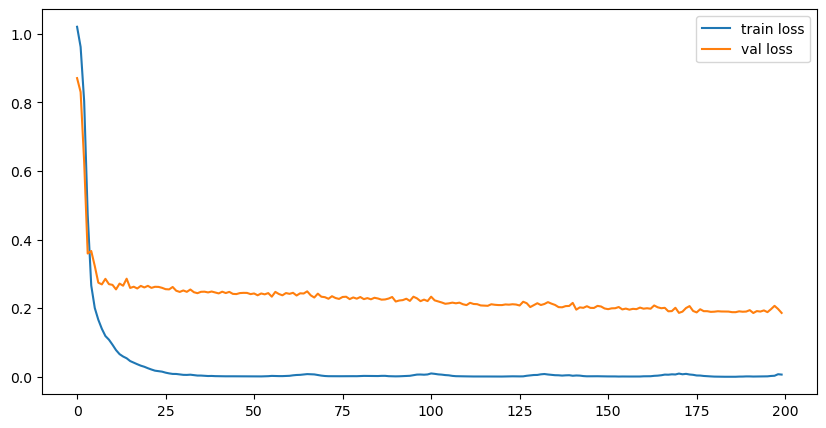

In [109]:
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(range(epochs), train_loss, label = 'train loss')
plt.plot(range(epochs), val_loss, label = 'val loss')
plt.legend()
plt.show()

### 규제(dropout) 정규화, early stopping

In [110]:
class AdvancedModel(nn.Module):
    def __init__(self, input_dim, dropout_p=0.3):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            # 정규화 레이어
            nn.ReLU(),
            # 드랍아웃 레이어
            
            nn.Linear(128, 64),
            # 정규화 레이어
            nn.ReLU(),
            # 드랍아웃 레이어

            nn.Linear(64, 32),
            # 정규화 레이어
            nn.ReLU(),
            # 드랍아웃 레이어

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)
    
model = AdvancedModel(input_dim=20)
print(model)

AdvancedModel(
  (network): Sequential(
    (0): Linear(in_features=20, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [111]:
new_layers = []
model = AdvancedModel(input_dim=20)
for i, layer in enumerate(list(model.network)):
    new_layers.append(layer)
    if isinstance(layer, nn.Linear) and i < len( list(model.network))-1:
        new_layers.append(nn.BatchNorm1d( layer.out_features ))
    if isinstance(layer, nn.ReLU):
        new_layers.append(nn.Dropout(0.3))

new_model = nn.Sequential(*new_layers)
new_model

Sequential(
  (0): Linear(in_features=20, out_features=128, bias=True)
  (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=128, out_features=64, bias=True)
  (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU()
  (7): Dropout(p=0.3, inplace=False)
  (8): Linear(in_features=64, out_features=32, bias=True)
  (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU()
  (11): Dropout(p=0.3, inplace=False)
  (12): Linear(in_features=32, out_features=1, bias=True)
)

In [112]:
from tqdm import tqdm
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion =  nn.MSELoss()
early_stopping = EarlyStopping(patience=5)

epochs = 200
train_loss = []; val_loss = []
pbar = tqdm(range(epochs))
for epoch in pbar:
    new_model.train()  # 드랍아웃과 배치정규화가 학습 및 평가할때 서로 다르게 동작하는걸 방지
    batch_train_losses = 0.0 ; batch_val_losses=0.0
    
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        output = new_model(batch_x)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        batch_train_losses += loss.item()
    train_loss.append( batch_train_losses / len(train_loader) )
    
    new_model.eval()
    with torch.no_grad(): # 불필요한 업데이트 방지(메모리 절약)
        for batch_x, batch_y in val_loader:
            output = new_model(batch_x)
            loss = criterion(output, batch_y)
            batch_val_losses += loss.item()
        val_loss.append( batch_val_losses / len(val_loader) )
    pbar.set_postfix({'Train' : f'{train_loss[-1]:.4f}',  'val' : f'{val_loss[-1]:.4f}'})

    if (epoch+1) % 40 == 0 or epoch == 0:
        tqdm.write(f'epoch {epoch+1} / {epochs} train loss : {train_loss[-1]:.4f}  val loss : {val_loss[-1]:.4f}')

  1%|          | 2/200 [00:00<00:14, 14.12it/s, Train=1.0827, val=0.8654]

epoch 1 / 200 train loss : 1.1774  val loss : 0.9003


 21%|██        | 42/200 [00:02<00:08, 19.20it/s, Train=0.4221, val=0.2686]

epoch 40 / 200 train loss : 0.4389  val loss : 0.2721


 41%|████      | 82/200 [00:04<00:06, 19.10it/s, Train=0.3265, val=0.2521]

...

epoch 120 / 200 train loss : 0.3226  val loss : 0.1993


 81%|████████  | 162/200 [00:08<00:02, 18.56it/s, Train=0.3132, val=0.1854]

epoch 160 / 200 train loss : 0.3195  val loss : 0.1865


100%|██████████| 200/200 [00:10<00:00, 18.78it/s, Train=0.2684, val=0.1922]

epoch 200 / 200 train loss : 0.2684  val loss : 0.1922


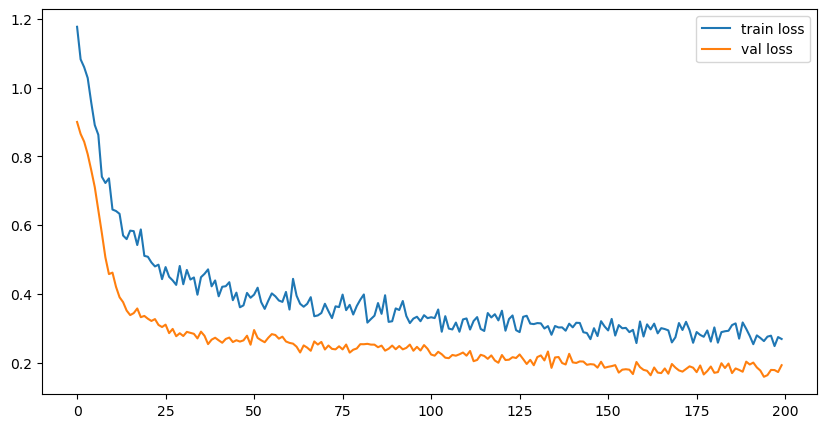

In [113]:
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(range(epochs), train_loss, label = 'train loss')
plt.plot(range(epochs), val_loss, label = 'val loss')
plt.legend()
plt.show()

In [114]:
class AdvancedModel(nn.Module):
    def __init__(self, input_dim, dropout_p=0.3):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            # 정규화 레이어
            nn.ReLU(),
            # 드랍아웃 레이어
            
            nn.Linear(128, 64),
            # 정규화 레이어
            nn.ReLU(),
            # 드랍아웃 레이어

            nn.Linear(64, 32),
            # 정규화 레이어
            nn.ReLU(),
            # 드랍아웃 레이어

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)
    
model = AdvancedModel(input_dim=20)
print(model)

AdvancedModel(
  (network): Sequential(
    (0): Linear(in_features=20, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [115]:
new_layers = []
model = AdvancedModel(input_dim=20)
for i, layer in enumerate(list(model.network)):
    new_layers.append(layer)
    if isinstance(layer, nn.Linear) and i < len( list(model.network))-1:
        new_layers.append(nn.BatchNorm1d( layer.out_features ))
    if isinstance(layer, nn.ReLU):
        new_layers.append(nn.Dropout(0.3))

new_model = nn.Sequential(*new_layers)
new_model

Sequential(
  (0): Linear(in_features=20, out_features=128, bias=True)
  (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=128, out_features=64, bias=True)
  (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU()
  (7): Dropout(p=0.3, inplace=False)
  (8): Linear(in_features=64, out_features=32, bias=True)
  (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU()
  (11): Dropout(p=0.3, inplace=False)
  (12): Linear(in_features=32, out_features=1, bias=True)
)

In [116]:
from tqdm import tqdm
optimizer = optim.Adam(new_model.parameters(), lr=1e-3)
criterion =  nn.MSELoss()
early_stopping = EarlyStopping(patience=7)

epochs = 2000
train_loss = []; val_loss = []
pbar = tqdm(range(epochs))

best_epoch = 0
for epoch in pbar:
    new_model.train()  # 드랍아웃과 배치정규화가 학습 및 평가할때 서로 다르게 동작하는걸 방지
    batch_train_losses = 0.0 ; batch_val_losses=0.0
    
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        output = new_model(batch_x)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        batch_train_losses += loss.item()    
    
    new_model.eval()
    with torch.no_grad(): # 불필요한 업데이트 방지(메모리 절약)
        for batch_val_x, batch_val_y in val_loader:            
            output = new_model(batch_val_x)
            loss = criterion(output, batch_val_y)            
            batch_val_losses += loss.item()            
            
    train_loss.append( batch_train_losses / len(train_loader) )
    val_loss.append(batch_val_losses / len(val_loader))    
    pbar.set_postfix({'Train' : f'{train_loss[-1]:.4f}',  'val' : f'{val_loss[-1]:.4f}'})

    if (epoch+1) % 20 == 0 or epoch == 0:
        tqdm.write(f'epoch {epoch+1} / {epochs} train loss : {train_loss[-1]:.4f}  val loss : {val_loss[-1]:.4f}')
    
    early_stopping(val_loss[-1],new_model)
    if early_stopping.eary_stop:
        print(f'ealy stopping {train_loss[-1]:.4f} val loss : {val_loss[-1]:.4f}')
        best_epoch = epoch
        break

  0%|          | 1/2000 [00:00<03:40,  9.07it/s, Train=1.0545, val=0.8949]

epoch 1 / 2000 train loss : 1.1785  val loss : 0.9287


  1%|          | 23/2000 [00:01<02:08, 15.34it/s, Train=0.4654, val=0.2986]

epoch 20 / 2000 train loss : 0.4858  val loss : 0.3142


  2%|▏         | 43/2000 [00:02<02:05, 15.63it/s, Train=0.3903, val=0.2703]

epoch 40 / 2000 train loss : 0.3641  val loss : 0.2318


  2%|▏         | 46/2000 [00:03<02:10, 14.92it/s, Train=0.3540, val=0.2435]

ealy stopping 0.3540 val loss : 0.2435


In [117]:
len(train_loss) , best_epoch

(47, 46)

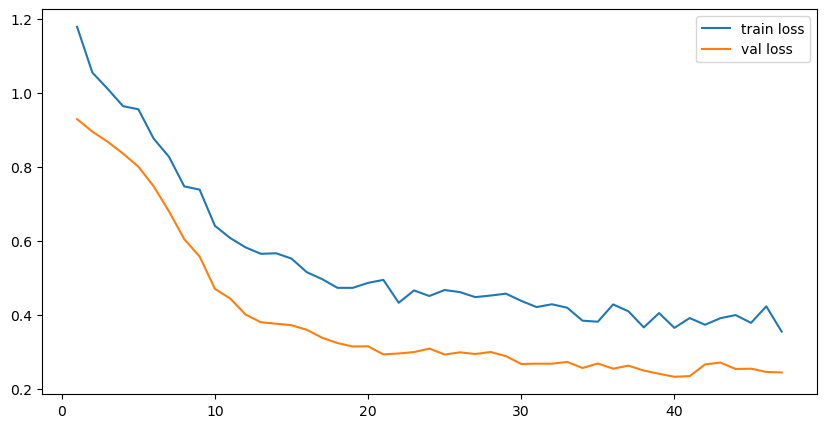

In [118]:
fig, ax = plt.subplots(figsize=(10,5))
plt.plot(range(1,best_epoch+2), train_loss, label = 'train loss')
plt.plot(range(1,best_epoch+2), val_loss, label = 'val loss')
plt.legend()
plt.show()